In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ASUS\Downloads\insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


tidak ada missing value disini

In [5]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [6]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [7]:
print(f"total sex : {df.sex.count()}")
print(f"total smoker : {df.smoker.count()}")
print(f"total region : {df.region.count()}")

total sex : 1338
total smoker : 1338
total region : 1338


so, all columns no missing values

In [8]:
print(f"total sex : {df.sex.unique()}")
print(f"total smoker : {df.smoker.unique()}")
print(f"total region : {df.region.unique()}")

total sex : <StringArray>
['female', 'male']
Length: 2, dtype: str
total smoker : <StringArray>
['yes', 'no']
Length: 2, dtype: str
total region : <StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


In [9]:
import numpy as np  

In [10]:
print(f"biaya premi minimum : {np.min(df.charges)}") 
print(f"biaya premi maximum : {np.max(df.charges)}")
print(f"biaya premi rata-rata : {np.mean(df.charges)}")
print(f"biaya premi median : {np.median(df.charges)}")
print(f"25% pasien membayar premi kurang dari : {np.percentile(df.charges, 25)}") # u can also use df.charges.quantile(0.25)
print(f"75% pasien membayar premi kurang dari : {np.percentile(df.charges, 75)}")

biaya premi minimum : 1121.8739
biaya premi maximum : 63770.42801
biaya premi rata-rata : 13270.422265141257
biaya premi median : 9382.033
25% pasien membayar premi kurang dari : 4740.28715
75% pasien membayar premi kurang dari : 16639.912515


In [11]:
print(f"standar deviasi biaya premi based on function numpy : {np.std(df.charges)}") #assume a population std by default, if you want to calculate sample std, use np.std(df.charges, ddof=1)
print(f"standar deviasi biaya premi based on function pandas : {df.charges.std()}") #assume a sample std by default, if you want to calculate population std, use df.charges.std(ddof=0)

standar deviasi biaya premi based on function numpy : 12105.484975561612
standar deviasi biaya premi based on function pandas : 12110.011236694001


In [12]:
from scipy.stats import skew, kurtosis

print(skew(df.charges, bias=False)) #skewness  bias=false itu karena ini hitungnya pakai sample bukan population
print(kurtosis(df.charges, bias=False)) #kurtosis

1.5158796580240383
1.6062986532967916


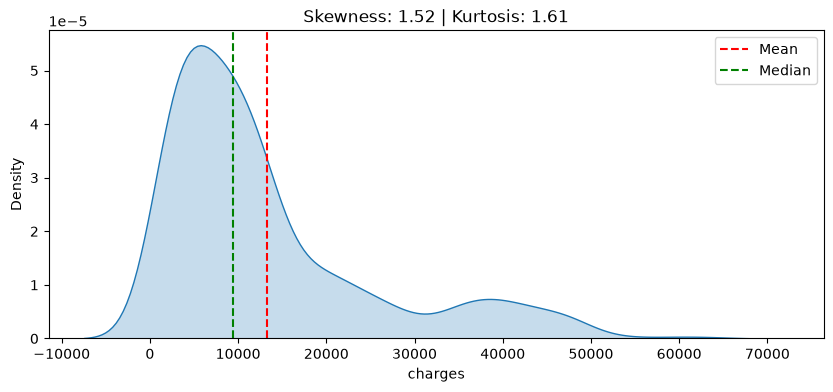

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
sns.kdeplot(df.charges, fill=True)
plt.axvline(df.charges.mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df.charges.median(), color='green', linestyle='--', label='Median')
plt.legend()
plt.title(f'Skewness: {skew(df.charges, bias=False):.2f} | Kurtosis: {kurtosis(df.charges, bias=False):.2f}')
plt.show()

skew ke kiri/kanan sih inii(?), menandakan banyak orang yang membayar lebih murah, disini juga trlihat bahwa median < dari mean. kurtosis, menandakan ada pasien-pasien dengan biaya yang jauh di atas rata-rata — bukan cuma sedikit lebih tinggi, tapi ekstrem. ( disini karena ada segmen tertentu dalam dataset ini, yaitu smoker or not).
Skew dan kurtosis tinggi = distribusi biaya tidak merata → perusahaan asuransi harus hati-hati dalam penetapan premi karena sebagian kecil nasabah bisa menyebabkan kerugian besar yang tidak proporsional.

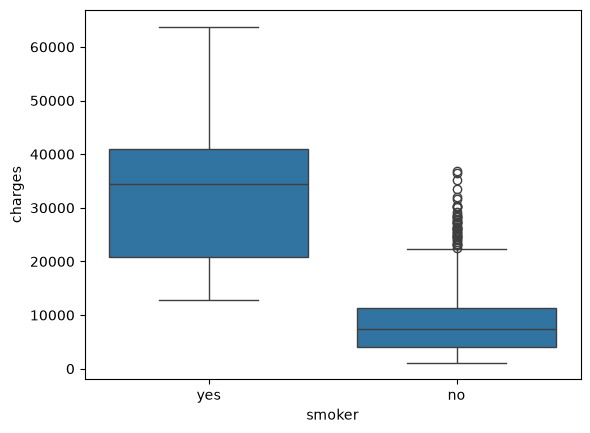

In [14]:
sns.boxplot(x='smoker', y='charges', data=df) #ini buat liat perbedaan biaya premi antara smoker dan non-smoker
plt.show()

# buletan ini namanya outlier, yaitu data yang berada di luar batas normal. Biasanya outlier ini bisa mempengaruhi hasil analisis kita, jadi kita perlu mengidentifikasi dan menangani outlier ini dengan baik.

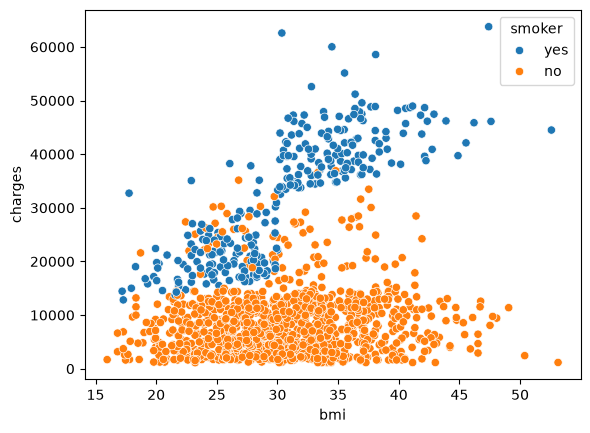

In [15]:
sns.scatterplot(x='bmi',y='charges',hue='smoker',data=df)
plt.show()

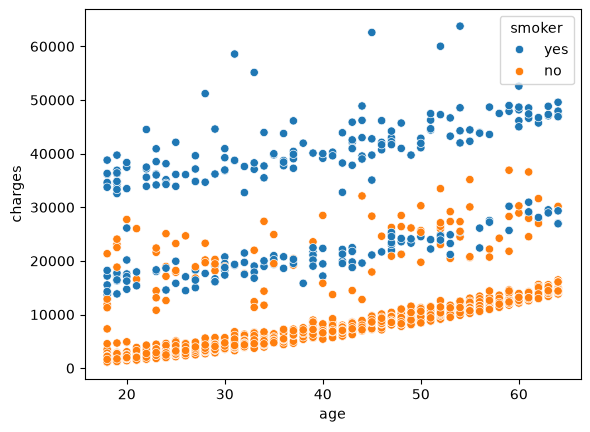

In [16]:
sns.scatterplot(x='age',y='charges',hue='smoker',data=df)
plt.show()

semakin tua memiliki kecenderungan charges semakin naik. smoker di usia berapapun cenderung chargesnya lebih tinggi daripada nonsmokers.

In [21]:
df[(df['smoker'] == 'no') & (df['charges'] > 30000)] # cari orang non smoker yang membayar premi lebih dari 30k

,age,sex,bmi,children,smoker,region,charges
62,64,male,24.700,1,no,northwest,30166.61817
115,60,male,28.595,0,no,northeast,30259.99556
242,55,female,26.800,1,no,southwest,35160.13457
387,50,male,25.365,2,no,northwest,30284.64294
573,62,female,36.860,1,no,northeast,31620.00106
599,52,female,37.525,2,no,northwest,33471.97189
936,44,male,29.735,2,no,northeast,32108.66282
1012,61,female,33.330,4,no,southeast,36580.28216
1206,59,female,34.800,2,no,southwest,36910.60803
1258,55,male,37.715,3,no,northwest,30063.58055


In [23]:
df[(df['smoker'] == 'no') & (df['charges'] > 30000)]['age'].mean() # rata-rata umur orang non smoker yang membayar premi lebih dari 30k

np.float64(56.2)

BUAT DUMMY VARIABLE

In [28]:
#categorical encoding , kita buat dia dummy variable, karena kita mau masukin ke model machine learning, jadi harus diubah ke angka dulu
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True,dtype=int) # drop_first=True itu biar ga ada dummy variable yang redundant, misal kita punya 2 kategori, misal laki-laki dan perempuan, kita cuma butuh 1 dummy variable aja, misal laki-laki = 1, perempuan = 0, jadi ga perlu bikin dummy variable untuk perempuan lagi, karena itu redundant. Jadi kita drop salah satu kategori aja.

df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


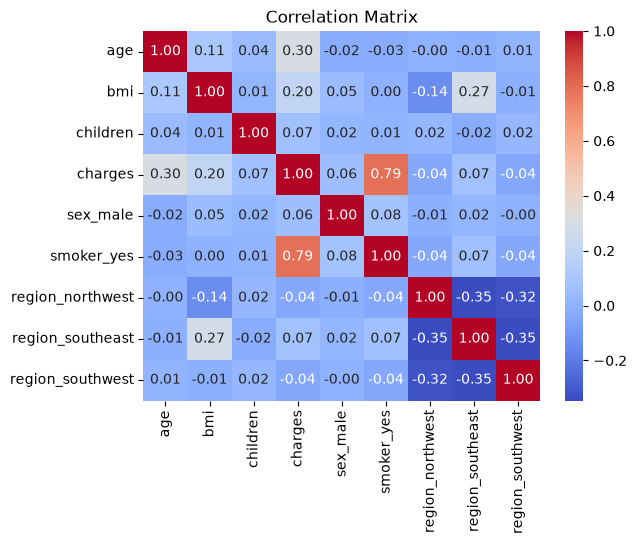

In [29]:
plt.Figure(figsize=(10, 8)) #10,8 itu ukuran figure, 10 itu lebar, 8 itu tinggi
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f") #annot=True itu biar ada angka di setiap kotak, cmap itu color map, fmt itu format angka, .2f itu 2 angka dibelakang koma
plt.title('Correlation Matrix')
plt.show()

In [30]:
corr_target = abs(df.corr()['charges'])

corr_target.sort_values(ascending=False)

charges             1.000000
smoker_yes          0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex_male            0.057292
region_southwest    0.043210
region_northwest    0.039905
Name: charges, dtype: float64

| 0.00 - 0.19 | sangat lemah |
| 0.20 - 0.39 | lemah |
| 0.40 - 0.59 | sedang |
| 0.60 - 0.79 | kuat |
| 0.80 - 1.00 | sangat kuat |

In [ ]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 435.3 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/8.3 MB 435.3 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/8.3 MB 435.3 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/8.3 MB 435.3 kB/s eta 0:00:18
   --- ------------------------------------ 0.8/8.3 MB 365.0 kB/s eta 0:00:21
   --- ------------------------------------ 0.8/8.3 MB 365.0 kB/s eta 0:00:21
   --- ------------------------------------ 0.8/8.3 MB 365.0 kB/s eta 0:00:21
   --- ------------------------------------ 0.8/8.3 MB 365.0 kB/s eta 0:00:21
   --- ------------------------

In [46]:
#independent and dependent variable
X = df.drop('charges', axis=1) #drop artinya hapus, axis=1 itu artinya hapus kolom, kalau axis=0 itu artinya hapus baris
y = df['charges']

#train test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15) #test_size=0.25 itu artinya 25% data untuk test, 75% data untuk train, random_state=42 itu artinya kita mau random data tapi kita mau hasilnya sama setiap kali kita run code ini
scaler = StandardScaler() #standard scaler itu artinya kita mau normalisasi data, biar data kita ga terlalu besar atau terlalu kecil, biar model kita ga terlalu bias ke data yang besar atau kecil
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
#training
from sklearn.linear_model import LinearRegression
regression = LinearRegression() #linear regression itu artinya kita mau bikin model linear, biar model kita ga terlalu kompleks, biar model kita ga overfitting
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[3657.07,2050.26, 682.91,..., -89.23,-509.78,-431.82]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.337e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[39.16,36.64,33.6 ,...,29.84,27.97,17.82]"


In [48]:
y_pred = regression.predict(X_test)

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred) #mean absolute error itu artinya kita mau ngitung rata-rata selisih antara nilai asli dan nilai prediksi, biar kita tau seberapa jauh prediksi kita dari nilai asli   
mse = mean_squared_error(y_test, y_pred) #mean squared error itu artinya kita mau ngitung rata-rata selisih kuadrat antara nilai asli dan nilai prediksi, biar kita tau seberapa jauh prediksi kita dari nilai asli
rmse = np.sqrt(mse) #root mean squared error itu artinya kita mau ngitung akar dari mean squared error, biar kita tau seberapa jauh prediksi kita dari nilai asli
r2 = r2_score(y_test, y_pred) #r2 score itu artinya kita mau ngitung seberapa baik model kita dalam memprediksi nilai asli, semakin mendekati 1 semakin baik
adjusted_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1) #adjusted r2 score itu artinya kita mau ngitung seberapa baik model kita dalam memprediksi nilai asli, tapi kita juga mau memperhitungkan jumlah fitur yang kita pake, semakin mendekati 1 semakin baik
print(f"mean absolute error : {mae:.2f}")
print(f"mean squared error : {mse:.2f}")
print(f"root mean squared error : {rmse:.2f}")
print(f"r2 score : {r2:.2f}")
print(f"adjusted r2 score : {adjusted_r2:.2f}")

mean absolute error : 4023.65
mean squared error : 30723136.83
root mean squared error : 5542.85
r2 score : 0.79
adjusted r2 score : 0.78


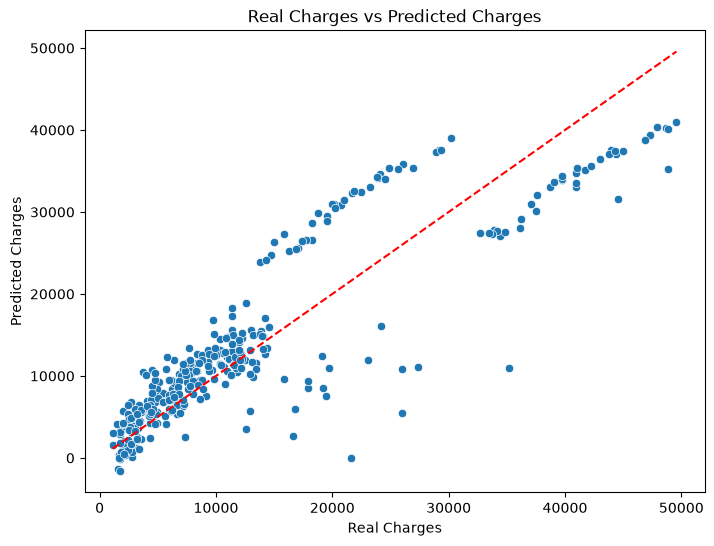

In [53]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel("Real Charges")
plt.ylabel("Predicted Charges")
plt.title("Real Charges vs Predicted Charges")
plt.show()

coba bandingin sama lasso ridge elasticnet

mean absolute error : 4023.60
mean squared error : 30721362.62
R² Score : 0.79


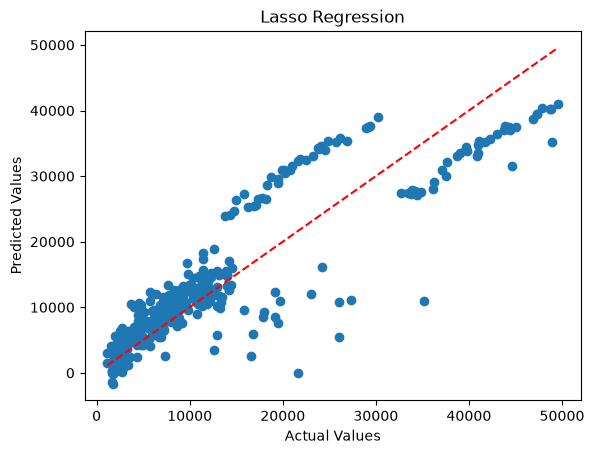

In [55]:
#lasso

from sklearn.linear_model import Ridge, Lasso, ElasticNet
lasso = Lasso()
lasso.fit(X_train, y_train) 

y_pred_lasso = lasso.predict(X_test)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
score = r2_score(y_test, y_pred_lasso)

print(f"mean absolute error : {mae_lasso:.2f}")
print(f"mean squared error : {mse_lasso:.2f}")
print(f"R² Score : {score:.2f}")

plt.scatter(y_test, y_pred_lasso)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Lasso Regression")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.show()



mean absolute error : 4024.91
mean squared error : 30715633.65
R² Score : 0.79


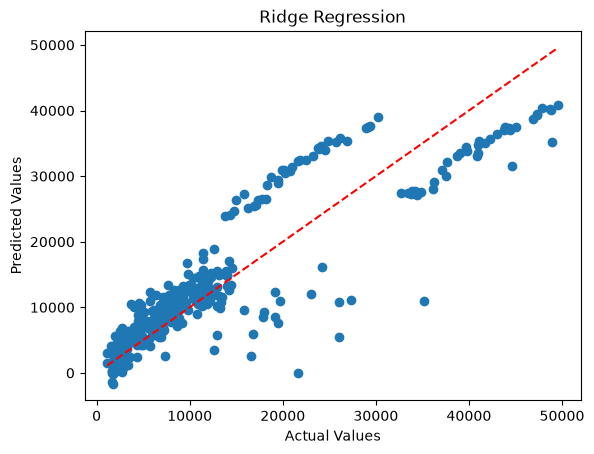

In [56]:
#ridge
ridge = Ridge()
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
score_ridge = r2_score(y_test, y_pred_ridge)

print(f"mean absolute error : {mae_ridge:.2f}")
print(f"mean squared error : {mse_ridge:.2f}")
print(f"R² Score : {score_ridge:.2f}")

plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Ridge Regression")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.show()

mean absolute error : 4997.00
mean squared error : 42389680.50
R² Score : 0.71


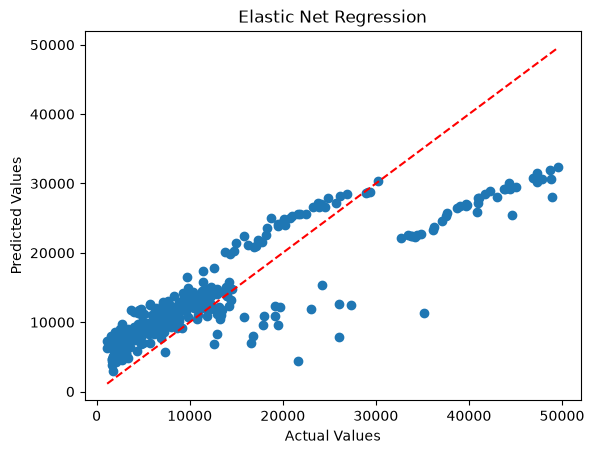

In [57]:
#elastic net
elastic_net = ElasticNet()
elastic_net.fit(X_train, y_train)

y_pred_elastic = elastic_net.predict(X_test)
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
score_elastic = r2_score(y_test, y_pred_elastic)

print(f"mean absolute error : {mae_elastic:.2f}")
print(f"mean squared error : {mse_elastic:.2f}")
print(f"R² Score : {score_elastic:.2f}")

plt.scatter(y_test, y_pred_elastic)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Elastic Net Regression")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.show()

cek overfitting ( selisih < 0,05 masih aman) dsn train > test

In [ ]:
models = {
    'Linear': regression,
    'Ridge': ridge,
    'Lasso': lasso,
    'ElasticNet': elastic_net
}

for name, model in models.items():
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, model.predict(X_test))
    print(f"{name} → Train: {train_r2:.2f} | Test: {test_r2:.2f}")

Linear → Train: 0.74 | Test: 0.79
Ridge → Train: 0.74 | Test: 0.79
Lasso → Train: 0.74 | Test: 0.79
ElasticNet → Train: 0.65 | Test: 0.71


mau linear regression,lasso, ridge. R square mereka sama2 ada di 0,79. so, masalahnya bukan overvitting, tapi modelnya memang udh di batas kemampuan model linear. malah kalo coba pakai elastic net, itu R squarenya drop ke 0,71.
nah kalau buat nembus R square > 0,79 , harus pakai yang lain, kayak interaction terms sana nonlinear model ( kayak random forest, XGBoost)

yukk coba ke interaction term duluuq

In [59]:
print(df.columns.tolist())

['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [ ]:
df['bmi_smoker'] = df['bmi'] * df['smoker_yes'] #buat fitur baru, yaitu interaksi antara bmi dan smoker, karena kita mau liat pengaruh bmi terhadap biaya premi, tapi kita juga mau liat pengaruh smoker terhadap biaya premi, jadi kita buat fitur baru yang merupakan interaksi antara bmi dan smoker

X = df[['age', 'bmi', 'children', 'smoker_yes','bmi_smoker']]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.model_selection import cross_val_score

print(f"R² Score on Test Set: {r2_score(y_test, y_pred):.2f}")
print(f"R² Score on Train Set: {r2_score(y_train, model.predict(X_train)):.2f}")

scores = cross_val_score(model, X, y, cv=5, scoring='r2') #merepresentasika test set yang diambil 5 kali
print("R² tiap fold:", scores)
print("R² rata-rata:", scores.mean())

R² Score on Test Set: 0.88
R² Score on Train Set: 0.82
R² tiap fold: [0.86192561 0.79281316 0.87649776 0.81486735 0.83382015]
R² rata-rata: 0.8359848040873603


In [ ]:
#tambah interaction term antara age dan smoker
df['age_smoker'] = df['age'] * df['smoker_yes']

X = df[['age', 'bmi', 'children', 'smoker_yes','bmi_smoker','age_smoker']]
y = df[['charges']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.model_selection import cross_val_score

print(f"R² Score on Test Set: {r2_score(y_test, y_pred):.2f}")
print(f"R² Score on Train Set: {r2_score(y_train, model.predict(X_train)):.2f}")

scores = cross_val_score(model, X, y, cv=5, scoring='r2') #merepresentasika test set yang diambil 5 kali
print("R² tiap fold:", scores)
print("R² rata-rata:", scores.mean())
print(f"nilai adjusted R² Score on Test Set: {1 - (1 - r2_score(y_test, y_pred)) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1):.2f}")

R² Score on Test Set: 0.88
R² Score on Train Set: 0.82
R² tiap fold: [0.86188203 0.79262121 0.87640223 0.8148565  0.83361101]
R² rata-rata: 0.8358745968784811
nilai adjusted R² Score on Test Set: 0.88


COBA DECISION TREE

In [89]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv(r"C:\Users\ASUS\Downloads\insurance.csv")
x = df.drop('charges', axis=1) #axis=1 itu artinya kita mau drop kolom, kalau axis=0 itu artinya kita mau drop baris
y = df['charges']

X = pd.get_dummies(x, drop_first=True, dtype=int) #drop_first=True itu artinya kita mau drop salah satu kategori, karena kalau kita ga drop salah satu kategori, nanti model kita bakal kebingungan, karena ada 2 kategori yang sama, misal laki-laki dan perempuan, kalau kita ga drop salah satu kategori, nanti model kita bakal kebingungan, karena ada 2 kategori yang sama, misal laki-laki dan perempuan, kalau kita ga drop salah satu kategori, nanti model kita bakal kebingungan, karena ada 2 kategori yang sama, misal laki-laki dan perempuan, kalau kita ga drop salah satu kategori, nanti model kita bakal kebingungan, karena ada 2 kategori yang sama, misal laki-laki dan perempuan


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(max_depth=4, random_state=42) #max
model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

# Calculate metrics

r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)

print(f"Test R²: {r2_test}")
print(f"Train R²: {r2_train}")


Test R²: 0.8641310379678357
Train R²: 0.8653110840097293


In [71]:
#feature importance
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
feature_imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_imp_df.head(10))

            feature  importance
4        smoker_yes    0.703212
1               bmi    0.178707
0               age    0.114492
2          children    0.003589
3          sex_male    0.000000
5  region_northwest    0.000000
6  region_southeast    0.000000
7  region_southwest    0.000000


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20072\997158684.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_imp_df.head(10), palette='viridis')


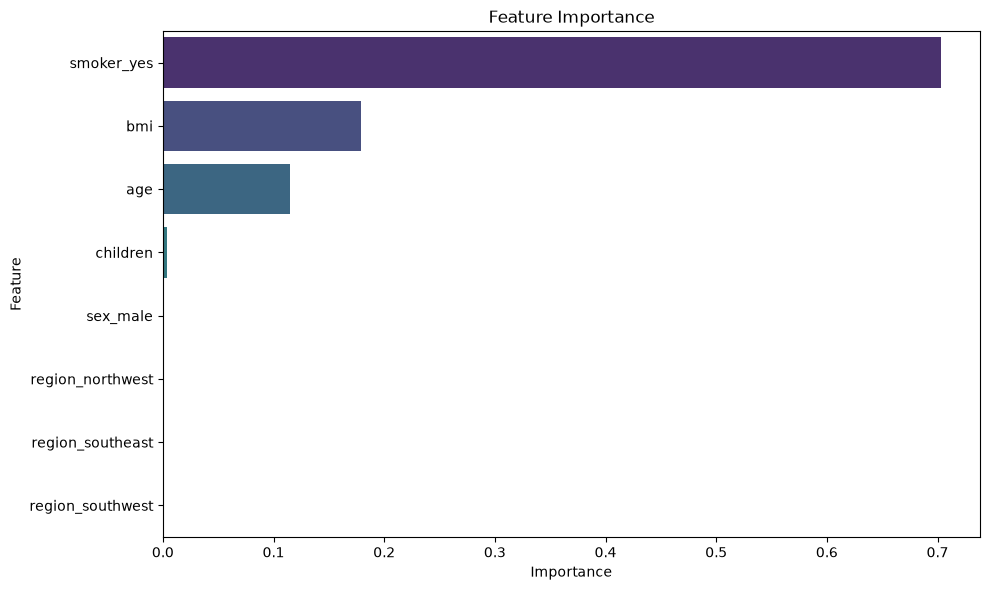

In [72]:
#visualization of feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_imp_df.head(10), palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [88]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Inisialisasi Random Forest
# Kita kunci max_depth=8 (sama seperti eksperimen terakhirmu)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)

# Proses ini mungkin akan memakan waktu beberapa detik lebih lama dari Decision Tree biasa
rf_model.fit(X_train, y_train)
# Prediksi data train dan test
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

# Hitung R2
print(f"Random Forest - R² Train Set: {r2_score(y_train, y_pred_rf_train):.4f}")
print(f"Random Forest - R² Test Set: {r2_score(y_test, y_pred_rf_test):.4f}")

Random Forest - R² Train Set: 0.8721
Random Forest - R² Test Set: 0.8709


yang ku lakukan terakhir ini, coba2 decision tree dengan max depth 5,6,7,8, ternyata 7,8 itu udah agak parah yhh ( selisih antara train dan test r2 nya tinggi). abis itu coba pakai random forest, pilih max depth 8 juga, sesuai yang di decision tree. pas dicek ternyata 
test
 decision tree : 0,7994  vs random forest : 0,8700
 train 
  decision tree : 0,9331  vs random forest : 0.9402

disini yang decisin tree overfit tapi yang forest engga, karena yang test dari dec ke forest dia cenderung naik, sednagkan yang train juga naik.

  coba  max depth 7 
  test
 decision tree : 0,8013  vs random forest : 0,8716
 train 
  decision tree : 0,9112  vs random forest : 0.9232

  kalo dibandingin antara forest 7 dan 8, maka forest 7 lebih baik dari forest 8


jierss ternyata coba max depth 4 doank lebih bagus.....
Random Forest - R² Train Set: 0.8721
Random Forest - R² Test Set: 0.8709
